# Analiza uticaja razvoja tehnologija veštačke inteligencije i kriptovaluta na cene grafičkih karti

## Autori
* Maja Varga R2 5/2024
* Nikola Simić E2 17/2024

## **PRVI DEO**: Eksplorativna analiza uticaja karakteristika grafičkih karti na profitabilnost kopanja kriptovalute
### UVOD
Cilj prvog dela ove analize je pronalazak ključnih karakteristika grafičkih karti koje utiču na profitabilnost kopanja kriptovalute. Na osnovu analize će biti izdvojene najbitnije karakteristike grafičkih karti, uz pomoć kojih će se izvršiti predikcija profitabilnosti za sve ostale karte. Razmatrane kriptovalute su *Monero* kao predstavnik algoritama kopanja koji primarno koriste procesorsku moć (*core-intensive*) i *Ethereum Classic* kao predstavnik algoritama koji primarno koriste memoriju (*memory-intensive*).

### Biblioteke koje se koriste:

In [230]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from pathlib import Path
from rapidfuzz import process, fuzz
from scipy.stats import pearsonr, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re
from io import StringIO
import warnings

# Ne prikazivati Jupyther upozorenja, radi preglednosti
warnings.filterwarnings('ignore')

### Pomoćne funkcije koje se koriste:

In [231]:
# Za numeričke podatke koji imaju sufikse ili prefikse (GB, Mhz itd.) koje samo treba parsirati u float
def extract_float(value):
    if pd.isna(value):
        return None
    match = re.search(r'[\d.]+', str(value))
    return float(match.group()) if match else None


# Za konverziju iz float-a u int
def extract_int(value):
    n = extract_float(value)
    if n is not None:
        return int(n)
    else:
        return None

# Slično extract_float funkciji
def to_num(x):
    if isinstance(x, str):
        x = re.sub(r'[^0-9.\-]', '', x)
    try:
        return float(x)
    except:
        return None

# Za uklanjanje znakova $ iz kolone cene i vraćanje konvertovane cene u float
def clean_currency(value):
    if pd.isna(value):
        return None
    cleaned = re.sub(r'[^0-9\.\-]', '', str(value))
    try:
        return float(cleaned)
    except ValueError:
        return None
    
# Za uklanjanje oznake cloud infrastrukture na kojoj su pokrenuti algoritmi za kopanje
def clean_gpu_name(name: str) -> str:
    remove_words = ['LambdaCloud', '1x']
    if pd.isna(name):
        return None
    name = name.lower()
    pattern = r'\b(?:' + '|'.join(remove_words) + r')\b'
    name = re.sub(pattern, '', name)
    name = re.sub(r'[^a-z0-9 ]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = re.sub(r"\s*\([^)]*\)", "", name).strip()
    name = re.sub(r"\b(LHR|FULL\s*UNLOCK|ENGINEERING SAMPLE)\b", "", name, flags=re.IGNORECASE)
    name = name.strip()
    return name

# Formatiranje datuma na Mesec Godina format, npr. Oct 2025
def format_date(value):
    if pd.isna(value):
        return None        
    try:
        dt = pd.to_datetime(value, errors='coerce')
        if pd.isna(dt):
            return value
        return dt.strftime("%b %Y")
    except Exception:
        return None

# Konverzija MB u KB (vezano za keš memoriju)
def mb_to_kb(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    match_mb = re.match(r'([\d\.]+)\s*MB', s, re.I)
    if match_mb:
        return float(match_mb[1]) * 1024

    match_kb = re.match(r'([\d\.]+)\s*KB', s, re.I)
    if match_kb:
        return float(match_kb[1])
    
    return None

# Konverzija GB u MB (vezano za memoriju)
def gb_to_mb(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    match_mb = re.match(r'([\d\.]+)\s*MB', s, re.I)
    if match_mb:
        return float(match_mb[1])
    match = re.match(r'([\d\.]+)\s*GB', str(value), re.I)
    if match:
        return float(match[1]) * 1024
    return None


# Konverzija TB/s u GB/s (vezano za Bandwidth)
def tb_to_gb(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    match_gb = re.match(r'([\d\.]+)\s*GB/s', s, re.I)
    if match_gb:
        return float(match_gb[1])
    match = re.match(r'([\d\.]+)\s*TB/s', str(value), re.I)
    if match:
        return float(match[1]) * 1024
    return None

# Konverzija TFLOPS u GFLOPS (vezano za broj floating-point operacija po sekundi)
def tf_to_gf(value):
    if pd.isna(value):
        return None
    s = str(value).replace(',', '').strip()

    match = re.match(r'([\d\.]+)\s*GFLOPS', s, re.I)
    if match:
        return float(match[1])
    match = re.match(r'([\d\.]+)\s*TFLOPS', str(value), re.I)
    if match:
        return float(match[1]) * 1000
    return value

Podaci koji se koriste se nalaze na putanji:

In [232]:
DATA_DIR = Path("D:/Fax/I semestar/Sistemi za istraživanje i analizu podataka/Projekat/consumer-gpu-price-analysis/data")

### Osnovni podaci o grafičkim kartama

**Napomena**: Pošto su podaci scrape-ovani sa Interneta, postoje greške u formatiranju koje zahtevaju predprocesiranje samih podataka. CSV fajl u kome se nalaze prikupljeni podaci izgleda ovako:

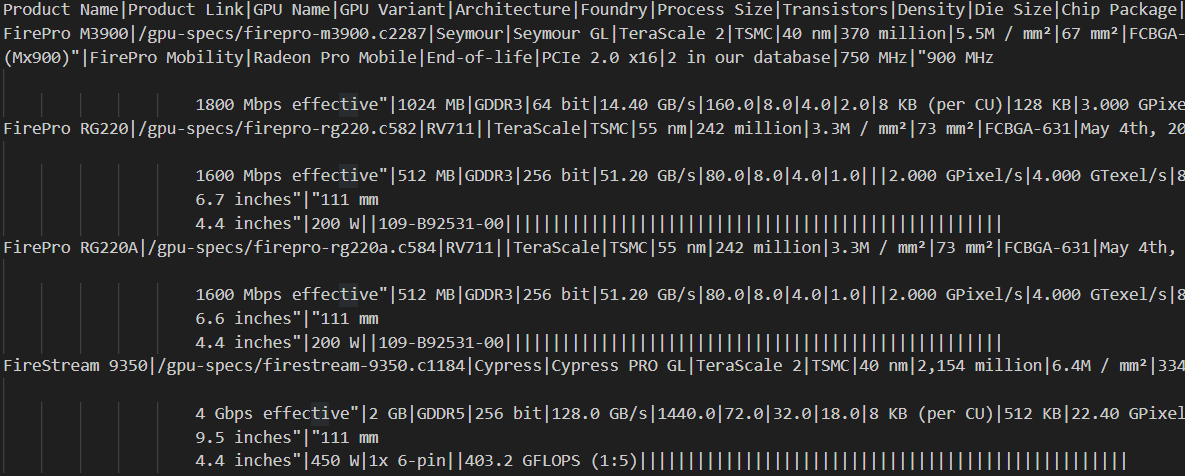

Dakle, potrebno je prvo spojiti razdvojene redove kako bi se dalje analizirali podaci. Nakon ovog predprocesiranja, podaci izgledaju ovako:

In [233]:
with open(f"{DATA_DIR}/gpu-details.csv", "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read()
raw_fixed = re.sub(r'"([^"]*)"', lambda m: m.group(0).replace('\n', ' '), raw)
raw_fixed = raw_fixed.replace('"', '')
raw_fixed = re.sub(r'[ \t]+', ' ', raw_fixed)
df_gpu = pd.read_csv(StringIO(raw_fixed), sep='|')
df_gpu

,Product Name,Product Link,GPU Name,GPU Variant,Architecture,Foundry,Process Size,Transistors,Density,Die Size,...,Pixel Shader,Vertex Shader,SMX Count,SMM Count,Tensor Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC
0,FirePro M3900,/gpu-specs/firepro-m3900.c2287,Seymour,Seymour GL,TeraScale 2,TSMC,40 nm,370 million,5.5M / mm²,67 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FirePro RG220,/gpu-specs/firepro-rg220.c582,RV711,NaN,TeraScale,TSMC,55 nm,242 million,3.3M / mm²,73 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FirePro RG220A,/gpu-specs/firepro-rg220a.c584,RV711,NaN,TeraScale,TSMC,55 nm,242 million,3.3M / mm²,73 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FireStream 9350,/gpu-specs/firestream-9350.c1184,Cypress,Cypress PRO GL,TeraScale 2,TSMC,40 nm,"2,154 million",6.4M / mm²,334 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FireStream 9370,/gpu-specs/firestream-9370.c1185,Cypress,Cypress XT GL,TeraScale 2,TSMC,40 nm,"2,154 million",6.4M / mm²,334 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,RTX PRO 5000 Blackwell,/gpu-specs/rtx-pro-5000-blackwell.c4276,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,440.0,NaN,NaN,NaN,NaN,NaN
1748,RTX PRO 6000 Blackwell,/gpu-specs/rtx-pro-6000-blackwell.c4272,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,752.0,NaN,NaN,NaN,NaN,NaN
1749,RTX PRO 6000 Blackwell Max-Q,/gpu-specs/rtx-pro-6000-blackwell-max-q.c4273,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,752.0,NaN,NaN,NaN,NaN,NaN
1750,RTX PRO 6000 Blackwell Server,/gpu-specs/rtx-pro-6000-blackwell-server.c4274,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,752.0,NaN,NaN,NaN,NaN,NaN


Postoje **1752** grafičke karte u skupu podataka sa **98** obeležja. Od svih obeležja, odabrana su sledeća koja su relevantna za izradu projektnog zadatka, a koja predstavljaju osnovne karakteristike grafičkih karti:
*Product Name, Base Clock, Boost Clock, Memory Clock, Memory Size, Memory Type, Memory Bus, Bandwidth, TDP, L1 Cache, L2 Cache, Shading Units, FP32 (float), Tensor Cores, Matrix Cores*.

- ***Product Name***: Naziv grafičke karte koji identifikuje model i proizvođača.

- ***Base Clock***: Osnovna radna frekvencija GPU-a u MHz koja određuje brzinu obrade podataka u normalnom režimu (numeričko obeležje).

- ***Boost Clock***: Maksimalna frekvencija GPU-a koju može dostići pri zahtevnim zadacima za bolje performanse (numeričko obeležje).

- ***Memory Clock***: Brzina memorije grafičke karte koja utiče na brzinu čitanja i pisanja podataka (numeričko obeležje).

- ***Memory Size***: Ukupna količina grafičke memorije (VRAM) koja omogućava skladištenje tekstura i podataka za obradu (numeričko obeležje).

- ***Memory Type***: Tip memorije (npr. GDDR6, HBM2) koji utiče na performanse i efikasnost memorijskog sistema (kategoričko obeležje).

- ***Memory Bus***: Širina memorijskog interfejsa u bitovima koja određuje koliko podataka GPU može istovremeno preneti (numeričko obeležje).

- ***Bandwidth***: Maksimalna količina podataka koju memorija može preneti po sekundi (numeričko obeležje).

- ***TDP***: *Thermal Design Power*, odnosno maksimalna potrošnja energije GPU-a u vatima (numeričko obeležje).

- ***L1 Cache***: Mali, brzi interni keš u GPU-u koji ubrzava pristup često korišćenim podacima (numeričko obeležje).

- ***L2 Cache***: Veća keš memorija koji služi za smanjenje kašnjenja pri čitanju podataka iz VRAM-a (numeričko obeležje).

- ***Shading Units***: Broj procesora (*CUDA processor* za *Nvidia*-u ili *Stream processor* za *AMD*) za paralelnu obradu grafičkih i računarskih zadataka (numeričko obeležje).

- ***FP32 (float)***: Teorijska snaga GPU-a u single-precision (32-bit) floating point operacijama (numeričko obeležje).

- ***Tensor Cores***: Specijalizovani procesori za ubrzanje operacija veštačke inteligencije i dubokog učenja.

- ***Matrix Cores***: Specijalizovani procesori za brze matriksne operacije, često korišćene u AI zadacima.

Izdvojene podatke je potrebno predprocesirati, kako bi se svi sveli na istu jedinicu - konkretno, potrebno je *Memory Size* svesti na megabajte, *Bandwidth* na gigabajte, *L1 Cache* i *L2 Cache* na kilobajte i *FP32 (float)* na gigaflopove (GFLOPS). Ime modela bi trebalo normalizovati da sadrži samo ključne reči (proizvođač, oznaka modela, broj serije i dodatne oznake poput Ti, Super, gigabajti RAM memorije), a za ostala polja ekstrahovati numeričku vrednost (odbaciti prefikse ili sufikse). Nakon ovog koraka, podaci o grafičkim kartama izgledaju ovako:

In [234]:
relevant_columns = [
    "Product Name",
    "Base Clock", "Boost Clock",
    "Memory Clock", "Memory Size", "Memory Type", "Memory Bus", "Bandwidth",
    "TDP", "L1 Cache", "L2 Cache",
    "Shading Units", "FP32 (float)", "Tensor Cores", 'Matrix Cores']
df_gpu = df_gpu[relevant_columns]
df_gpu['Product Name'] = df_gpu['Product Name'].apply(clean_gpu_name)
df_gpu['Base Clock'] = df_gpu['Base Clock'].apply(extract_float)
df_gpu['Boost Clock'] = df_gpu['Boost Clock'].apply(extract_float)
df_gpu['Memory Clock'] = df_gpu['Memory Clock'].apply(extract_float)
df_gpu['Memory Size'] = df_gpu['Memory Size'].apply(gb_to_mb)
df_gpu['Memory Bus'] = df_gpu['Memory Bus'].apply(extract_int)
df_gpu['Memory Type'] = df_gpu['Memory Type'].str.strip()
df_gpu['Bandwidth'] = df_gpu['Bandwidth'].apply(tb_to_gb)

df_gpu['TDP'] = df_gpu['TDP'].apply(extract_float)
df_gpu['L1 Cache'] = df_gpu['L1 Cache'].apply(mb_to_kb)
df_gpu['L2 Cache'] = df_gpu['L2 Cache'].apply(mb_to_kb)
df_gpu['Shading Units'] = df_gpu['Shading Units'].apply(extract_int)
df_gpu['FP32 (float)'] = df_gpu['FP32 (float)'].apply(tf_to_gf)
df_gpu['Tensor Cores'] = df_gpu['Tensor Cores'].apply(extract_int)
df_gpu['Matrix Cores'] = df_gpu['Matrix Cores'].apply(extract_int)
df_gpu

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN


In [235]:
df_gpu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Tensor Cores   286 non-null    float64
 14  Matrix Cores   19 non-null     float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Samo *Product Name* i *Memory Type* su zabeleženi za sve grafičke karte - procena nedostajućih vrednosti će biti urađena za sva ostala polja. 

U nastavku slede posebne analize za *Monero* i *Ethereum Classic* kriptovalute.
### Monero

#### Skup podataka sa kojim se radi:

**Napomena**: Pošto su podaci scrape-ovani sa Interneta, postoje greške u formatiranju koje zahtevaju predprocesiranje samih podataka. CSV fajl u kome se nalaze prikupljeni podaci izgleda ovako:

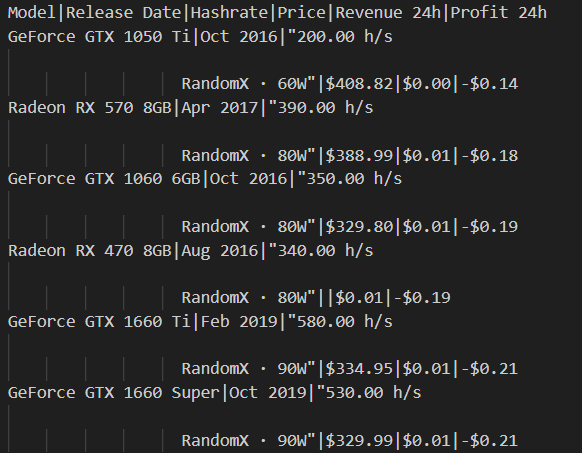

Dakle, potrebno je spojiti redove koji su podeljeni na više redova i izvući *hashrate* u jedinici h/s, izbaciti specifikaciju algoritma koji se koristi (RandomX), normalizovati ime modela da sadrži samo ključne reči (proizvođač, oznaka modela, broj serije i dodatne oznake poput Ti, Super, gigabajti RAM memorije) i ekstrahovati zaradu (posmatramo ***Revenue 24h*** kao ciljno obeležje, s obzirom na to da *Profit 24h* uzima u obzir i troškove struje koja je potrebna za kopanje kriptovaluti, što je relativna informacija koja varira u odnosu na region i način snabdevanja). Funkcija koja će izvršiti potrebno predprocesiranje je sledeća:

In [236]:
def clean_mining_csv(file_path: str) -> pd.DataFrame:
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read()
    raw_fixed = re.sub(r'"([^"]*)"', lambda m: m.group(0).replace('\n', ' '), raw)
    raw_fixed = raw_fixed.replace('"', '')
    raw_fixed = re.sub(r'RandomX\s*·\s*', '', raw_fixed, flags=re.IGNORECASE)
    raw_fixed = re.sub(r'[ \t]+', ' ', raw_fixed)
    df = pd.read_csv(StringIO(raw_fixed), sep='|')

    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

    df['Model'] = df['Model'].apply(clean_gpu_name)
    df = df.drop_duplicates(subset=["Model"], keep="first")
    
    df['Hashrate'] = df['Hashrate'].str.replace(
        r'(\d+(?:\.\d+)?)\s*[kK]\s*h/s',
        lambda m: str(float(m.group(1)) * 1000) + ' h/s',
        regex=True
    )

    df['Hashrate'] = df['Hashrate'].str.replace(
        r'(\d+(?:\.\d+)?)\s*[mM]\s*h/s',
        lambda m: str(float(m.group(1)) * 1000000) + ' h/s',
        regex=True
    )

    df['Hashrate'] = df['Hashrate'].str.extract(r'([\d.]+)').astype(float)

    df['Revenue 24h'] = df['Revenue 24h'].apply(clean_currency)

    return df[['Model', 'Hashrate', 'Revenue 24h']]

Podaci koji se dobiju nakon predprocesiranja izgledaju ovako:

In [237]:
df_mining = clean_mining_csv(f"{DATA_DIR}/mining-gpus-101-xmr-randomx.csv")
df_mining

,Model,Hashrate,Revenue 24h
0,geforce gtx 1050 ti,200.0,0.00
1,radeon rx 570 8gb,390.0,0.01
2,geforce gtx 1060 6gb,350.0,0.01
3,radeon rx 470 8gb,340.0,0.01
4,geforce gtx 1660 ti,580.0,0.01
5,geforce gtx 1660 super,530.0,0.01
6,geforce gtx 1660,530.0,0.01
7,radeon rx 480 8gb,470.0,0.01
8,radeon rx 580 8gb,470.0,0.01
9,geforce rtx 2060,600.0,0.01


In [238]:
df_mining.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 0 to 24
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Model        23 non-null     object 
 1   Hashrate     23 non-null     float64
 2   Revenue 24h  23 non-null     float64
dtypes: float64(2), object(1)
memory usage: 736.0+ bytes


- ***Model*** – Naziv i varijanta grafičke karte koja definiše njen tip i arhitekturu.

- ***Hashrate*** – Brzina kojom grafička karta izvršava kriptografske proračune tokom rudarenja izražena u h/s.

- ***Revenue 24h*** – Procenjena zarada koju ta grafička karta ostvari u toku 24 sata rudarenja izražena u dolarima (**bez uračunatih troškova struje**).

Vizuelnom analizom podataka se može pretpostaviti da se povećanjem *hashrate*-a povećava i zarada. 

In [239]:
pearson_corr, pearson_p = pearsonr(df_mining['Hashrate'], df_mining['Revenue 24h'])
print(f"Pirsonov koeficijent: {pearson_corr}. Relevantno obeležje: {pearson_p < 0.05}")

Pirsonov koeficijent: 0.973287493173651. Relevantno obeležje: True


Pirsonov koeficijent pokazuje da je odnos između povećanja *hashrate*-a i zarade skoro linearan - zato možemo ukloniti *hashrate* iz razmatranih karakteristika GPU-a, jer znamo kakav odnos ima na konačnu zaradu.

In [240]:
df_mining = df_mining[['Model', 'Revenue 24h']]

Podaci o specifikaciji grafičke karte i o profitabilnosti kopanja su preuzeti sa različitih sajtova - postoje manja odstupanja u imenovanju modela grafičke karte. Kako je za dalju analizu potrebno da se ova dva skupa podataka spoje u jedan jedinstveni (u kome će samo mali broj imati zabeležen *Hashrate* i *Revenue 24h*), iskoristićemo *fuzzy* poklapanje stringova. Podaci nakon spajanja izgledaju ovako:

In [241]:
def fuzzy_merge(df_mining: pd.DataFrame, df_gpu: pd.DataFrame, threshold=85) -> pd.DataFrame:
    df_mining = df_mining.copy()
    df_gpu = df_gpu.copy()
    df_gpu['Revenue 24h'] = pd.NA

    gpu_names = df_gpu["Product Name"].tolist()

    for _, mining_row in df_mining.iterrows():
        mining_name = mining_row["Model"]
        
        best_match = process.extractOne(
            mining_name, 
            gpu_names, 
            scorer=fuzz.ratio
        )
    
        if best_match:
            matched_name, score, index = best_match
            if score >= threshold:
                print(f"{mining_name} <=> {matched_name} (%: {score})")
                df_gpu.at[index, 'Revenue 24h'] = mining_row['Revenue 24h']
        
    df_gpu['Revenue 24h'] = pd.to_numeric(df_gpu['Revenue 24h'], errors='coerce')
    return df_gpu

df_merged = fuzzy_merge(df_mining, df_gpu)
df_merged

geforce gtx 1050 ti <=> geforce gtx 1050 ti (%: 100.0)
radeon rx 570 8gb <=> radeon rx 570 (%: 86.66666666666667)
geforce gtx 1060 6gb <=> geforce gtx 1060 6 gb (%: 97.5609756097561)
radeon rx 470 8gb <=> radeon rx 470 (%: 86.66666666666667)
geforce gtx 1660 ti <=> geforce gtx 1660 ti (%: 100.0)
geforce gtx 1660 super <=> geforce gtx 1660 super (%: 100.0)
geforce gtx 1660 <=> geforce gtx 1660 (%: 100.0)
radeon rx 480 8gb <=> radeon rx 480 (%: 86.66666666666667)
radeon rx 580 8gb <=> radeon rx 580g (%: 90.32258064516128)
geforce rtx 2060 <=> geforce rtx 2060 (%: 100.0)
geforce gtx 1080 <=> geforce gtx 1080 (%: 100.0)
geforce gtx 1070 ti <=> geforce gtx 1070 ti (%: 100.0)
geforce gtx 1070 <=> geforce gtx 1070 (%: 100.0)
geforce rtx 2070 <=> geforce rtx 2070 (%: 100.0)
radeon rx vega 56 <=> radeon rx vega 56 (%: 100.0)
geforce rtx 2080 <=> geforce rtx 2080 (%: 100.0)
radeon rx vega 64 <=> radeon rx vega 64 (%: 100.0)
geforce rtx 3070 <=> geforce rtx 3070 (%: 100.0)
geforce gtx 1080 ti <=>

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores,Revenue 24h
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN


In [242]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Tensor Cores   286 non-null    float64
 14  Matrix Cores   19 non-null     float64
 15  Revenue 24h    23 non-null     float64
dtypes: float64(14), object(2)
memory usage: 219.1+ KB


*Tensor Cores* i *Matrix Cores* su srodna imena za specijalizovana jezgra za izvršavanje računskih operacija u AI zadacima - razlika je samo u proizvođaču (za *Nvidia*-u su *Tensor Cores*, a za *AMD* su *Matrix Cores*). Potebno ih je spojiti u jednu jedinstvenu kolonu. <br>
**Napomena**: Za sve grafičke karte za koje nije naveden broj specijalizovanih jezgra se podrazumeva da ih nemaju.

In [243]:
def get_ai_cores(row):

    model = str(row.get("Product Name", "")).lower()

    if any(keyword in model for keyword in ["nvidia", "geforce", "gtx", "rtx"]):
        cores = row.get("Tensor Cores", 0)
        return 0 if pd.isna(cores) else cores
    
    elif any(keyword in model for keyword in ["amd", "radeon", "firepro", "firestream"]):
        cores = row.get("Matrix Cores", 0)
        return 0 if pd.isna(cores) else cores
      
    return 0
df_merged["AI Cores"] = df_merged.apply(get_ai_cores, axis=1)
df_merged = df_merged.drop(columns=["Tensor Cores", "Matrix Cores"], errors="ignore")
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Revenue 24h    23 non-null     float64
 14  AI Cores       1752 non-null   float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Nedostajuće vrednosti atributa se moraju proceniti. Za potrebe procene atributa biće isprobana dva algoritma - ***Decision Tree*** i ***Random Forest***. Izračunaće se RMSE za oba algoritma, i odabrati onaj koji ima najmanju grešku za sve kolone za koje će se vršiti procena nedostajućih vrednosti. <br>
Želimo da uključimo i kategoričko obeležje *Memory Type* u kolone na osnovu kojih će se vrednosti procenjivati - to obeležje ćemo enkodirati *One Hot Encoder*-om.

In [244]:
def impute_numeric_columns(df: pd.DataFrame, random_state=42):
    df = df.copy()

    categorical_cols = ["Memory Type"]
    original_cats = df[categorical_cols].copy()

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if "Revenue 24h" in numeric_cols:
        numeric_cols.remove("Revenue 24h")

    models = {
        "DecisionTree": DecisionTreeRegressor(random_state=random_state),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=random_state)
    }

    total_rmse = {name: 0 for name in models.keys()}
    column_scores = {}

    for col in numeric_cols:
        n_missing = df[col].isna().sum()
        if n_missing == 0:
            continue

        df_train = df[df[col].notna()]
        df_pred = df[df[col].isna()]

        features = [c for c in numeric_cols if c != col]

        X = df_train[features].fillna(df_train[features].median())
        y = df_train[col]
        X_pred = df_pred[features].fillna(df_train[features].median())

        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=0.2, random_state=random_state
        )

        scores = {}
        for name, model in models.items():
            model.fit(X_tr, y_tr)
            y_pred_val = model.predict(X_val)
            rmse = np.sqrt(root_mean_squared_error(y_val, y_pred_val))
            scores[name] = rmse
            total_rmse[name] += rmse
        print(f"Kolona: {col} -> RMSE: {scores}")
        column_scores[col] = scores

    best_model_name = min(total_rmse, key=total_rmse.get)
    best_model_class = models[best_model_name]

    print(f"Najbolji model: {best_model_name} (prema ukupnoj RMSE greški)")
    print(f"Ukupna RMSE greška: {total_rmse}")

    for col in numeric_cols:
        if df[col].isna().sum() == 0:
            continue

        df_train = df[df[col].notna()]
        df_pred = df[df[col].isna()]
        if df_pred.empty:
            continue

        features = [c for c in numeric_cols if c != col]
        X = df_train[features].fillna(df_train[features].median())
        y = df_train[col]
        X_pred = df_pred[features].fillna(df_train[features].median())

        best_model = best_model_class
        best_model.fit(X, y)
        df.loc[df[col].isna(), col] = best_model.predict(X_pred)

    for col in categorical_cols:
        df[col] = original_cats[col]

    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    df.drop(columns=encoded_cols, inplace=True)

    return df

df_merged = impute_numeric_columns(df_merged)

Kolona: Base Clock -> RMSE: {'DecisionTree': np.float64(13.731773831899032), 'RandomForest': np.float64(12.024859457186277)}
Kolona: Boost Clock -> RMSE: {'DecisionTree': np.float64(14.841040807209964), 'RandomForest': np.float64(11.841716828874914)}
Kolona: Memory Clock -> RMSE: {'DecisionTree': np.float64(11.246383790577434), 'RandomForest': np.float64(10.135493953515375)}
Kolona: Memory Size -> RMSE: {'DecisionTree': np.float64(69.76816159956397), 'RandomForest': np.float64(65.85592879689696)}
Kolona: Memory Bus -> RMSE: {'DecisionTree': np.float64(7.950173367550373), 'RandomForest': np.float64(11.823162034961527)}
Kolona: Bandwidth -> RMSE: {'DecisionTree': np.float64(7.8111733189327), 'RandomForest': np.float64(9.188079226642504)}
Kolona: TDP -> RMSE: {'DecisionTree': np.float64(7.557932739452543), 'RandomForest': np.float64(6.438695849145705)}
Kolona: L1 Cache -> RMSE: {'DecisionTree': np.float64(3.755183162025437), 'RandomForest': np.float64(3.6043344576738257)}
Kolona: L2 Cache

In [245]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1752 non-null   float64
 2   Boost Clock    1752 non-null   float64
 3   Memory Clock   1752 non-null   float64
 4   Memory Size    1752 non-null   float64
 5   Memory Bus     1752 non-null   float64
 6   Bandwidth      1752 non-null   float64
 7   TDP            1752 non-null   float64
 8   L1 Cache       1752 non-null   float64
 9   L2 Cache       1752 non-null   float64
 10  Shading Units  1752 non-null   float64
 11  FP32 (float)   1752 non-null   float64
 12  Revenue 24h    23 non-null     float64
 13  AI Cores       1752 non-null   float64
 14  Memory Type    1752 non-null   object 
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Dakle, podaci su procenjeni *Random Forest* algoritmom koji je imao najmanju globalnu RMSE grešku. *Revenue 24h* se **ne procenjuje**, pošto predstavlja ciljnu promenljivu.

Sledeći korak je analiza uticaja svih atributa grafičkih karti na zaradu pri rudarenju. Cilj ovog koraka je izdvajanje najbitnijih obeležja koja će se koristiti za finalnu predikciju zarade za sve ostale grafičke karte za koje ovaj podatak ne postoji. <br>
Za analizu linearnih zavisnosti između karakteristika grafičkih karti i zarade koristiće se **Pirsonov** statistički test. Za analizu zavisnosti između kategoričkog obeležja *Memory Type* i zarade koristiće se **ANOVA** statistički test.

In [246]:
def analyze_revenue_influence(df: pd.DataFrame, revenue_col="Revenue 24h"):
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != revenue_col]
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    categorical_cols = [c for c in categorical_cols if c != revenue_col]
    categorical_cols.remove('Product Name')
    results = []

    for col in numeric_cols:
        if df[col].nunique() > 1: 
            pearson_corr, pearson_p = pearsonr(df[col], df[revenue_col])
            results.append({
                'attribute': col,
                'type': 'numeric',
                'pearson_corr': pearson_corr,
                'pearson_p': pearson_p,
            })

    for col in categorical_cols:
        groups = [group[revenue_col].values for name, group in df.groupby(col) if len(group) > 0]
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            results.append({
                'attribute': col,
                'type': 'categorical',
                'f_stat': f_stat,
                'p_value': p_value
            })

    numeric_results = sorted([r for r in results if r['type']=='numeric'], 
                             key=lambda x: abs(x['pearson_corr']), reverse=True)

    categorical_results = sorted([r for r in results if r['type']=='categorical'], 
                                 key=lambda x: x['p_value'])

    return numeric_results, categorical_results

numeric_res, categorical_res = analyze_revenue_influence(df_merged[df_merged['Revenue 24h'].notna()])
df_numeric_monero = pd.DataFrame(numeric_res)
df_categorical_monero = pd.DataFrame(categorical_res)
df_numeric_monero


,attribute,type,pearson_corr,pearson_p
0,TDP,numeric,0.923827,3.232468e-10
1,Bandwidth,numeric,0.918942,6.074052e-10
2,L2 Cache,numeric,0.897371,6.563953e-09
3,Shading Units,numeric,0.877651,3.798532e-08
4,FP32 (float),numeric,0.872727,5.620312e-08
5,Memory Size,numeric,0.843895,4.198804e-07
6,Memory Clock,numeric,-0.575900,4.030832e-03
7,AI Cores,numeric,0.569826,4.532536e-03
8,L1 Cache,numeric,0.446124,3.286296e-02
9,Memory Bus,numeric,0.416886,4.781844e-02


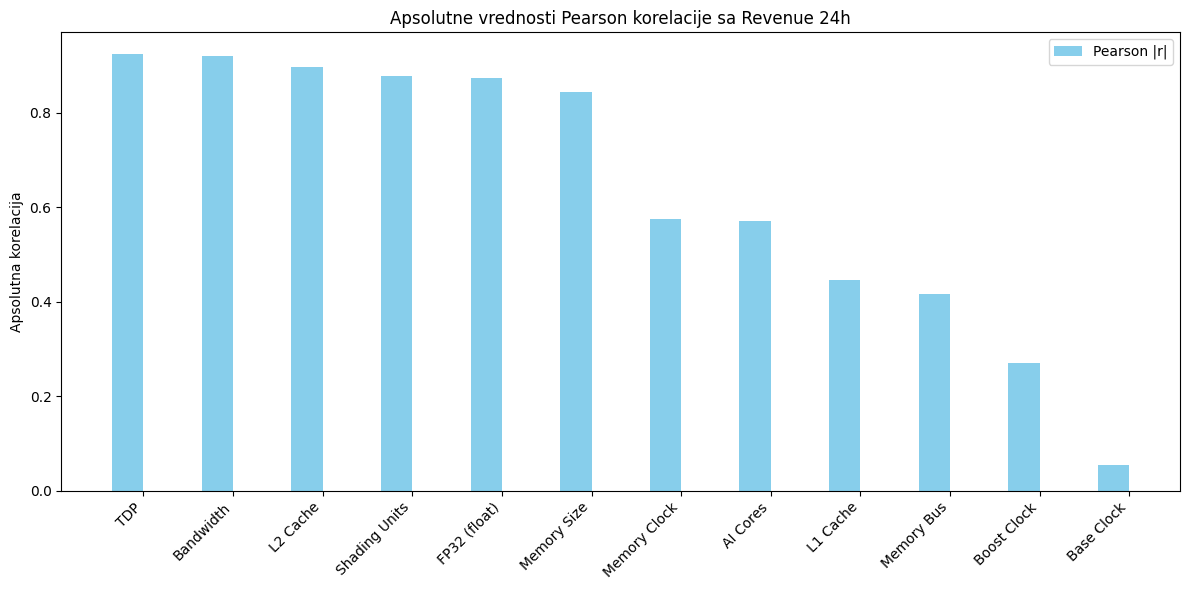

In [247]:
df_numeric_sorted = df_numeric_monero.sort_values(by='pearson_corr', key=abs, ascending=False)

plt.figure(figsize=(12,6))
bar_width = 0.35
index = range(len(df_numeric_sorted))

plt.bar(index, df_numeric_sorted['pearson_corr'].abs(), bar_width, label='Pearson |r|', color='skyblue')

plt.xticks([i + bar_width/2 for i in index], df_numeric_sorted['attribute'], rotation=45, ha='right')
plt.ylabel("Apsolutna korelacija")
plt.title("Apsolutne vrednosti Pearson korelacije sa Revenue 24h")
plt.legend()
plt.tight_layout()
plt.show()

In [248]:
df_categorical_monero

,attribute,type,f_stat,p_value
0,Memory Type,categorical,9.604788,0.000244


Prema rezultatima statističkih testova možemo zaključiti da su sva obeležja statistički značajna (**p vrednost za svako obeležje je manje od 0.05**). Posmatrajući rezultate testa za numerička obeležja, posebno se izdvaja jaka linearna korelacija između zarade i *TDP, Bandwidth, L2 Cache, Shading Units, FP32 (float)* i *Memory Size* obeležja. Ona će biti izdvojena za finalnu predikciju zarade.<br>
Posmatrajući rezultate testa za kategoričko obeležje *Memory Type*, zaključuje se da je prosečna zarada u različitim grupama tipa memorije značajno različita, tj. da postoji jak uticaj tipa memorije na zaradu. Stoga, i ovo obeležje će biti iskorišteno za finalnu predikciju zarade.

Krajnji korak je predikcija zarade u odnosu na izdvojena ključna obeležja (karakteristike) grafičkih karti. Za potrebu rešavanja ovog problema će biti iskorišteni *Decision Tree* i *Random Forest* algoritmi, za koje će se računati RMSE i MAE greška. Odabraće se model koji ima najmanju grešku po obe metrike, i njime će se napraviti predikcija svih ostalih zarada.

In [249]:
def predict_revenue(df: pd.DataFrame, important_features: list, revenue_col="Revenue 24h", n_splits=5, random_state=42):
    available_features = [f for f in important_features if f in df.columns]

    df_model = df[available_features + [revenue_col]].copy()

    categorical_features = df_model.select_dtypes(include=['object']).columns.tolist()
    if categorical_features:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = encoder.fit_transform(df_model[categorical_features])
        encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features), index=df_model.index)
        df_model = pd.concat([df_model.drop(columns=categorical_features), encoded_df], axis=1)

    df_known = df_model[df_model[revenue_col].notnull()].copy()
    df_missing = df_model[df_model[revenue_col].isnull()].copy()

    X = df_known.drop(columns=[revenue_col])
    y = df_known[revenue_col]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=random_state),
        "Random Forest": RandomForestRegressor(random_state=random_state, n_estimators=200)
    }

    metrics = {name: {"MAE": [], "RMSE": []} for name in models.keys()}

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        for name, model in models.items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            mae = mean_absolute_error(y_test, preds)
            rmse = root_mean_squared_error(y_test, preds)
            metrics[name]["MAE"].append(mae)
            metrics[name]["RMSE"].append(rmse)

    avg_metrics = {}
    for name in metrics:
        avg_metrics[name] = {
            "MAE": np.mean(metrics[name]["MAE"]),
            "RMSE": np.mean(metrics[name]["RMSE"])
        }
        print(f"\n{name}:")
        print(f"Prosečan MAE  = {avg_metrics[name]['MAE']:.4f}")
        print(f"Prosečan RMSE = {avg_metrics[name]['RMSE']:.4f}")

    best_model_name = min(avg_metrics, key=lambda k: avg_metrics[k]["MAE"])
    best_model = models[best_model_name]

    best_model.fit(X, y)

    if not df_missing.empty:
        X_missing = df_missing.drop(columns=[revenue_col])
        predicted_values = best_model.predict(X_missing)
        df.loc[df[revenue_col].isnull(), revenue_col] = predicted_values

    min_revenue = df["Revenue 24h"].min()
    max_revenue = df["Revenue 24h"].max()

    print(f"\nNajmanja zarada: {min_revenue:.4f}")
    print(f"Najveća zarada: {max_revenue:.4f}")
    return df, avg_metrics, best_model_name

df_merged, _, _ = predict_revenue(df_merged, ['TDP', 'Bandwidth', 'L2 Cache', 'FP32 (float)', 'Memory Size', 'Shading Units', 'Memory Type'])
df_merged


Decision Tree:
Prosečan MAE  = 0.0022
Prosečan RMSE = 0.0036

Random Forest:
Prosečan MAE  = 0.0026
Prosečan RMSE = 0.0038

Najmanja zarada: 0.0000
Najveća zarada: 0.0400


,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Revenue 24h,AI Cores,Memory Type
0,firepro m3900,962.745833,978.020,900.0,1024.0,64.0,14.40,20.0,8.00,128.00,160.0,240.0,0.00,0.0,GDDR3
1,firepro rg220,986.583667,950.725,800.0,512.0,256.0,51.20,35.0,25.08,64.32,80.0,80.0,0.00,0.0,GDDR3
2,firepro rg220a,986.583667,950.725,800.0,512.0,256.0,51.20,35.0,25.08,64.32,80.0,80.0,0.00,0.0,GDDR3
3,firestream 9350,1121.005000,1211.455,1000.0,2048.0,256.0,128.00,150.0,8.00,512.00,1440.0,2016.0,0.00,0.0,GDDR5
4,firestream 9370,1114.030000,1211.915,1150.0,4096.0,256.0,147.20,225.0,8.00,512.00,1600.0,2640.0,0.00,0.0,GDDR5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.000000,2617.000,1750.0,49152.0,384.0,1372.16,300.0,128.00,98304.00,14080.0,73690.0,0.04,440.0,GDDR7
1748,rtx pro 6000 blackwell,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.04,752.0,GDDR7
1749,rtx pro 6000 blackwell max q,1590.000000,2288.000,1750.0,98304.0,512.0,1832.96,300.0,128.00,131072.00,24064.0,110100.0,0.04,752.0,GDDR7
1750,rtx pro 6000 blackwell server,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.04,752.0,GDDR7


In [250]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1752 non-null   float64
 2   Boost Clock    1752 non-null   float64
 3   Memory Clock   1752 non-null   float64
 4   Memory Size    1752 non-null   float64
 5   Memory Bus     1752 non-null   float64
 6   Bandwidth      1752 non-null   float64
 7   TDP            1752 non-null   float64
 8   L1 Cache       1752 non-null   float64
 9   L2 Cache       1752 non-null   float64
 10  Shading Units  1752 non-null   float64
 11  FP32 (float)   1752 non-null   float64
 12  Revenue 24h    1752 non-null   float64
 13  AI Cores       1752 non-null   float64
 14  Memory Type    1752 non-null   object 
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Odabrani algoritam je bio ***Decision Tree***, koji je imao najmanju grešku i po RMSE i po MAE.<br>
U nastavku sledi sličan postupak i za *Ethereum Classic*.

### Ethereum Classic

Proces koji je opisan za *Monero* se ponavlja i ovde - razlike će potencijalno biti u odabiru ključnih obeležja za finalnu predikciju zarade pri kopanju ove kriptovalute. Skup podataka je takođe *scrape*-ovani sa Interneta i postoje greške u formatiranju:

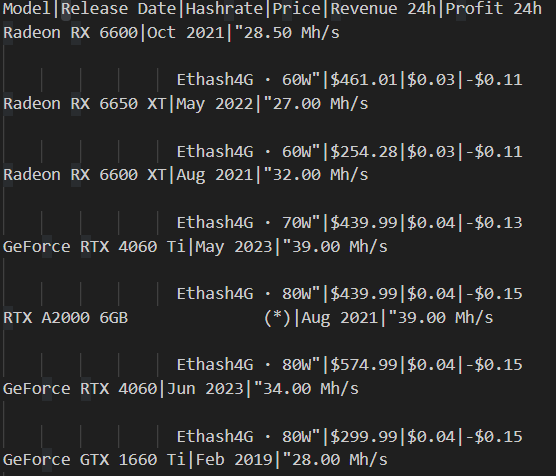


U nastavku sledi ponovljeni postupak reformatiranja, transformacije podataka, procene nedostajućih vrednosti i analize korelacija između karakteristika grafičkih karti sa zaradom prilikom kopanja *Ethereum Classic* kriptovalute.

#### Reformatiranje i transformacija skupa podataka

In [251]:
df_mining = clean_mining_csv(f"{DATA_DIR}/mining-gpus-162-etc-etchash.csv")
df_mining

,Model,Hashrate,Revenue 24h
0,radeon rx 6600,28500000.0,0.03
1,radeon rx 6650 xt,27000000.0,0.03
2,radeon rx 6600 xt,32000000.0,0.04
3,geforce rtx 4060 ti,39000000.0,0.04
4,rtx a2000 6gb,39000000.0,0.04
...,...,...,...
70,geforce rtx 3080 12gb,101500000.0,0.11
71,radeon rx 7900 xt,83000000.0,0.09
72,geforce rtx 3090,119000000.0,0.13
73,geforce rtx 3080 ti,117000000.0,0.13


In [252]:
df_mining.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 0 to 74
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Model        70 non-null     object 
 1   Hashrate     70 non-null     float64
 2   Revenue 24h  70 non-null     float64
dtypes: float64(2), object(1)
memory usage: 2.2+ KB


#### Analiza korelacije *hashrate*-a sa zaradom

In [253]:
pearson_corr, pearson_p = pearsonr(df_mining['Hashrate'], df_mining['Revenue 24h'])
print(f"Pirsonov koeficijent: {pearson_corr}. Relevantno obeležje: {pearson_p < 0.05}")

Pirsonov koeficijent: 0.9963486355224738. Relevantno obeležje: True


Opet zaključujemo da *hashrate* ima skoro savršenu linearnu korelaciju sa zaradom - ne razmatramo ga u daljoj analizi.

### Spajanje skupa podataka o grafičkim kartama sa podacima o zaradama, grupisanje specijalizovanih jezgara u jednu kolonu

In [254]:
df_mining = df_mining[['Model', 'Revenue 24h']]
df_merged = fuzzy_merge(df_mining, df_gpu)
df_merged

radeon rx 6600 <=> radeon rx 6600 (%: 100.0)
radeon rx 6650 xt <=> radeon rx 6650 xt (%: 100.0)
radeon rx 6600 xt <=> radeon rx 6600 xt (%: 100.0)
geforce rtx 4060 ti <=> geforce rtx 4060 ti (%: 100.0)
rtx a2000 6gb <=> rtx a2000 12 gb (%: 85.71428571428572)
geforce rtx 4060 <=> geforce rtx 4060 (%: 100.0)
geforce gtx 1660 ti <=> geforce gtx 1660 ti (%: 100.0)
geforce rtx 3050 <=> geforce rtx 3050 (%: 100.0)
geforce gtx 1660 <=> geforce gtx 1660 (%: 100.0)
radeon rx 6750 xt <=> radeon rx 6750 xt (%: 100.0)
geforce gtx 1050 ti <=> geforce gtx 1050 ti (%: 100.0)
geforce gtx 1660 super <=> geforce gtx 1660 super (%: 100.0)
radeon rx 5500 xt 8gb <=> radeon rx 5500 xt (%: 89.47368421052632)
radeon rx 6700 xt <=> radeon rx 6700 xt (%: 100.0)
geforce gtx 1060 6gb <=> geforce gtx 1060 6 gb (%: 97.5609756097561)
radeon rx 6800 xt <=> radeon rx 6800 xt (%: 100.0)
radeon rx 6800 <=> radeon rx 6800 (%: 100.0)
geforce rtx 4070 ti <=> geforce rtx 4070 ti (%: 100.0)
geforce rtx 3060 <=> geforce rtx 3

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores,Revenue 24h
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN


In [255]:
df_merged["AI Cores"] = df_merged.apply(get_ai_cores, axis=1)
df_merged = df_merged.drop(columns=["Tensor Cores", "Matrix Cores"], errors="ignore")
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Revenue 24h    70 non-null     float64
 14  AI Cores       1752 non-null   float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


#### Procena nedostajućih vrednosti (osim ciljnog obeležja zarade)

In [256]:
df_merged = impute_numeric_columns(df_merged)
df_merged.info()

Kolona: Base Clock -> RMSE: {'DecisionTree': np.float64(13.731773831899032), 'RandomForest': np.float64(12.024859457186277)}
Kolona: Boost Clock -> RMSE: {'DecisionTree': np.float64(14.841040807209964), 'RandomForest': np.float64(11.841716828874914)}
Kolona: Memory Clock -> RMSE: {'DecisionTree': np.float64(11.246383790577434), 'RandomForest': np.float64(10.135493953515375)}
Kolona: Memory Size -> RMSE: {'DecisionTree': np.float64(69.76816159956397), 'RandomForest': np.float64(65.85592879689696)}
Kolona: Memory Bus -> RMSE: {'DecisionTree': np.float64(7.950173367550373), 'RandomForest': np.float64(11.823162034961527)}
Kolona: Bandwidth -> RMSE: {'DecisionTree': np.float64(7.8111733189327), 'RandomForest': np.float64(9.188079226642504)}
Kolona: TDP -> RMSE: {'DecisionTree': np.float64(7.557932739452543), 'RandomForest': np.float64(6.438695849145705)}
Kolona: L1 Cache -> RMSE: {'DecisionTree': np.float64(3.755183162025437), 'RandomForest': np.float64(3.6043344576738257)}
Kolona: L2 Cache

#### Analiza korelacija između obeležja grafičkih karti sa ciljnim obeležjem zarade

In [257]:
numeric_res, categorical_res = analyze_revenue_influence(df_merged[df_merged['Revenue 24h'].notna()])
df_numeric_eth = pd.DataFrame(numeric_res)
df_categorical_eth = pd.DataFrame(categorical_res)
df_numeric_eth

,attribute,type,pearson_corr,pearson_p
0,Bandwidth,numeric,0.945526,7.336548e-35
1,Shading Units,numeric,0.911677,5.722453e-28
2,TDP,numeric,0.865424,4.326222e-22
3,FP32 (float),numeric,0.853694,6.063839e-21
4,Memory Size,numeric,0.830714,5.808897e-19
5,AI Cores,numeric,0.649664,1.167325e-09
6,L2 Cache,numeric,0.573294,2.136694e-07
7,L1 Cache,numeric,0.499448,1.075228e-05
8,Boost Clock,numeric,0.346133,3.334162e-03
9,Base Clock,numeric,0.278312,1.965345e-02


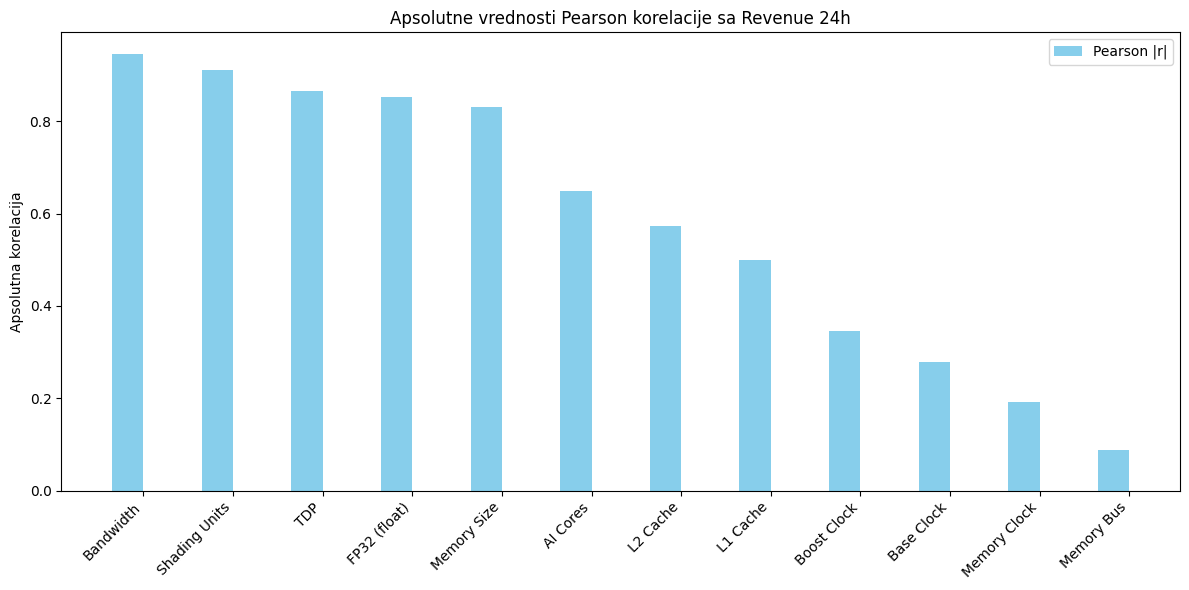

In [258]:
df_numeric_sorted = df_numeric_eth.sort_values(by='pearson_corr', key=abs, ascending=False)

plt.figure(figsize=(12,6))
bar_width = 0.35
index = range(len(df_numeric_sorted))

plt.bar(index, df_numeric_sorted['pearson_corr'].abs(), bar_width, label='Pearson |r|', color='skyblue')

plt.xticks([i + bar_width/2 for i in index], df_numeric_sorted['attribute'], rotation=45, ha='right')
plt.ylabel("Apsolutna korelacija")
plt.title("Apsolutne vrednosti Pearson korelacije sa Revenue 24h")
plt.legend()
plt.tight_layout()
plt.show()

Primećujemo da su u ovom slučaju ključne karakteristike grafičkih karti za kopanje *memory intensive* kriptovaluti *Bandwidth, Shading Units, TDP, FP32 (float)* i *Memory Size* atributi.

In [259]:
df_categorical_eth

,attribute,type,f_stat,p_value
0,Memory Type,categorical,14.029129,4.603139e-10


U ovom slučaju *Memory Type* ima još veći uticaj na zaradu, pošto je razlika između prosečnih zarada za svaki tip memorije još veća. Razmatraće se i ovo obeležje za predikciju zarade. 

In [260]:
df_merged, _, _ = predict_revenue(df_merged, ['TDP', 'Bandwidth', 'FP32 (float)', 'Memory Size', 'Shading Units', 'Memory Type'])
df_merged


Decision Tree:
Prosečan MAE  = 0.0087
Prosečan RMSE = 0.0127

Random Forest:
Prosečan MAE  = 0.0075
Prosečan RMSE = 0.0103

Najmanja zarada: 0.0100
Najveća zarada: 0.1800


,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Revenue 24h,AI Cores,Memory Type
0,firepro m3900,962.745833,978.020,900.0,1024.0,64.0,14.40,20.0,8.00,128.00,160.0,240.0,0.01820,0.0,GDDR3
1,firepro rg220,986.583667,950.725,800.0,512.0,256.0,51.20,35.0,25.08,64.32,80.0,80.0,0.01820,0.0,GDDR3
2,firepro rg220a,986.583667,950.725,800.0,512.0,256.0,51.20,35.0,25.08,64.32,80.0,80.0,0.01820,0.0,GDDR3
3,firestream 9350,1121.005000,1211.455,1000.0,2048.0,256.0,128.00,150.0,8.00,512.00,1440.0,2016.0,0.02125,0.0,GDDR5
4,firestream 9370,1114.030000,1211.915,1150.0,4096.0,256.0,147.20,225.0,8.00,512.00,1600.0,2640.0,0.01890,0.0,GDDR5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.000000,2617.000,1750.0,49152.0,384.0,1372.16,300.0,128.00,98304.00,14080.0,73690.0,0.13510,440.0,GDDR7
1748,rtx pro 6000 blackwell,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.16460,752.0,GDDR7
1749,rtx pro 6000 blackwell max q,1590.000000,2288.000,1750.0,98304.0,512.0,1832.96,300.0,128.00,131072.00,24064.0,110100.0,0.14765,752.0,GDDR7
1750,rtx pro 6000 blackwell server,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.16460,752.0,GDDR7


Odabrani algoritam za predikciju cena u ovom slučaju je *Random Forest*. 

### Zaključak

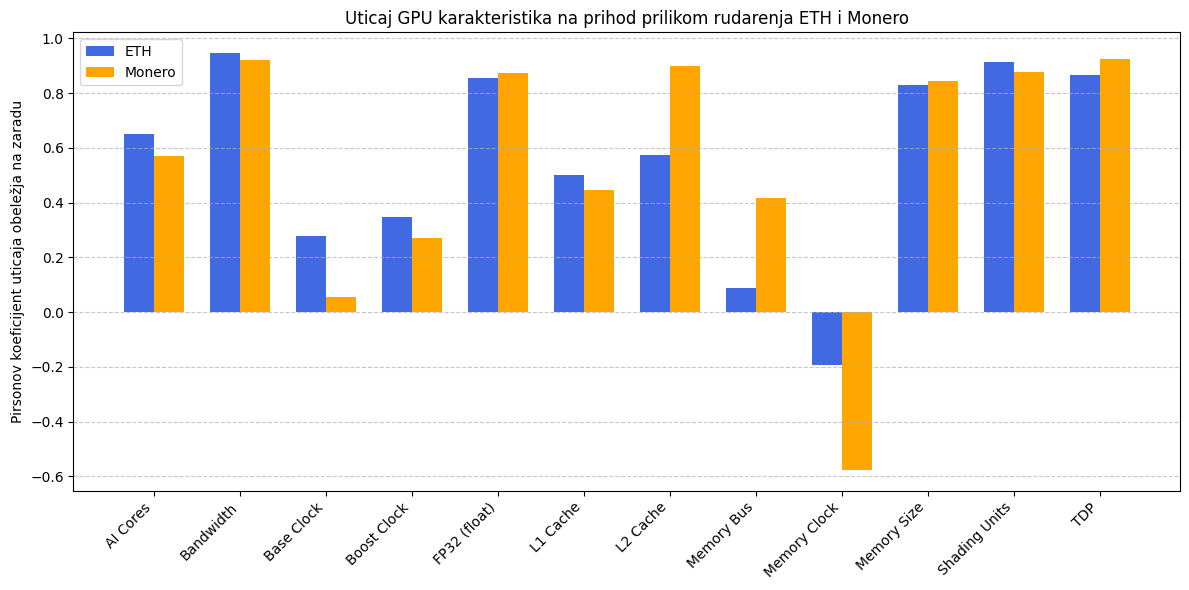

In [261]:
all_attributes = sorted(set(df_numeric_eth['attribute']).union(df_numeric_monero['attribute']))

# Napravi liste korelacija, ako atribut ne postoji u nekom DF-u stavi 0
eth_corrs = [df_numeric_eth.loc[df_numeric_eth['attribute']==a, 'pearson_corr'].values[0]
             if a in df_numeric_eth['attribute'].values else 0 for a in all_attributes]

monero_corrs = [df_numeric_monero.loc[df_numeric_monero['attribute']==a, 'pearson_corr'].values[0]
                if a in df_numeric_monero['attribute'].values else 0 for a in all_attributes]

x = np.arange(len(all_attributes))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width/2, eth_corrs, width, label='ETH', color='royalblue')
ax.bar(x + width/2, monero_corrs, width, label='Monero', color='orange')

ax.set_ylabel('Pirsonov koeficijent uticaja obeležja na zaradu')
ax.set_title('Uticaj GPU karakteristika na prihod prilikom rudarenja ETH i Monero')
ax.set_xticks(x)
ax.set_xticklabels(all_attributes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Prema izvršenoj analizi je uočeno da postoji skup numeričkih karakteristika grafičkih karti koje su generalno bitne za zaradu prilikom kopanja kriptovalute: *Bandwidth, FP32 (float), Memory Size, Shading Units* i *TDP*. *Memory Type* je kategoričko obeležje koja je takođe generalno bitno za zaradu, pri čemu ima još veći uticaj na zaradu prilikom kopanja *core intensive* kriptovalute - u ovom slučaju *Ethereum classic*. Takođe, uočeno je da veći *Memory clock* zapravo ne predstavlja prednost za kopanje kriptovaluti bilo kog tipa, samo ima negativniji uticaj na *core intensive* algoritme kopanja.  